見つかったファイル: ['results_pz_0.0_Lx_6_Nd_1000_NT_1080.npz']
results_pz_0.0_Lx_6_Nd_1000_NT_1080.npz → Lx=6, Nd=1000, NT=1080, pz=0.0
results_pz_0.0_Lx_6_Nd_1000_NT_1080.npz: Lx= 6


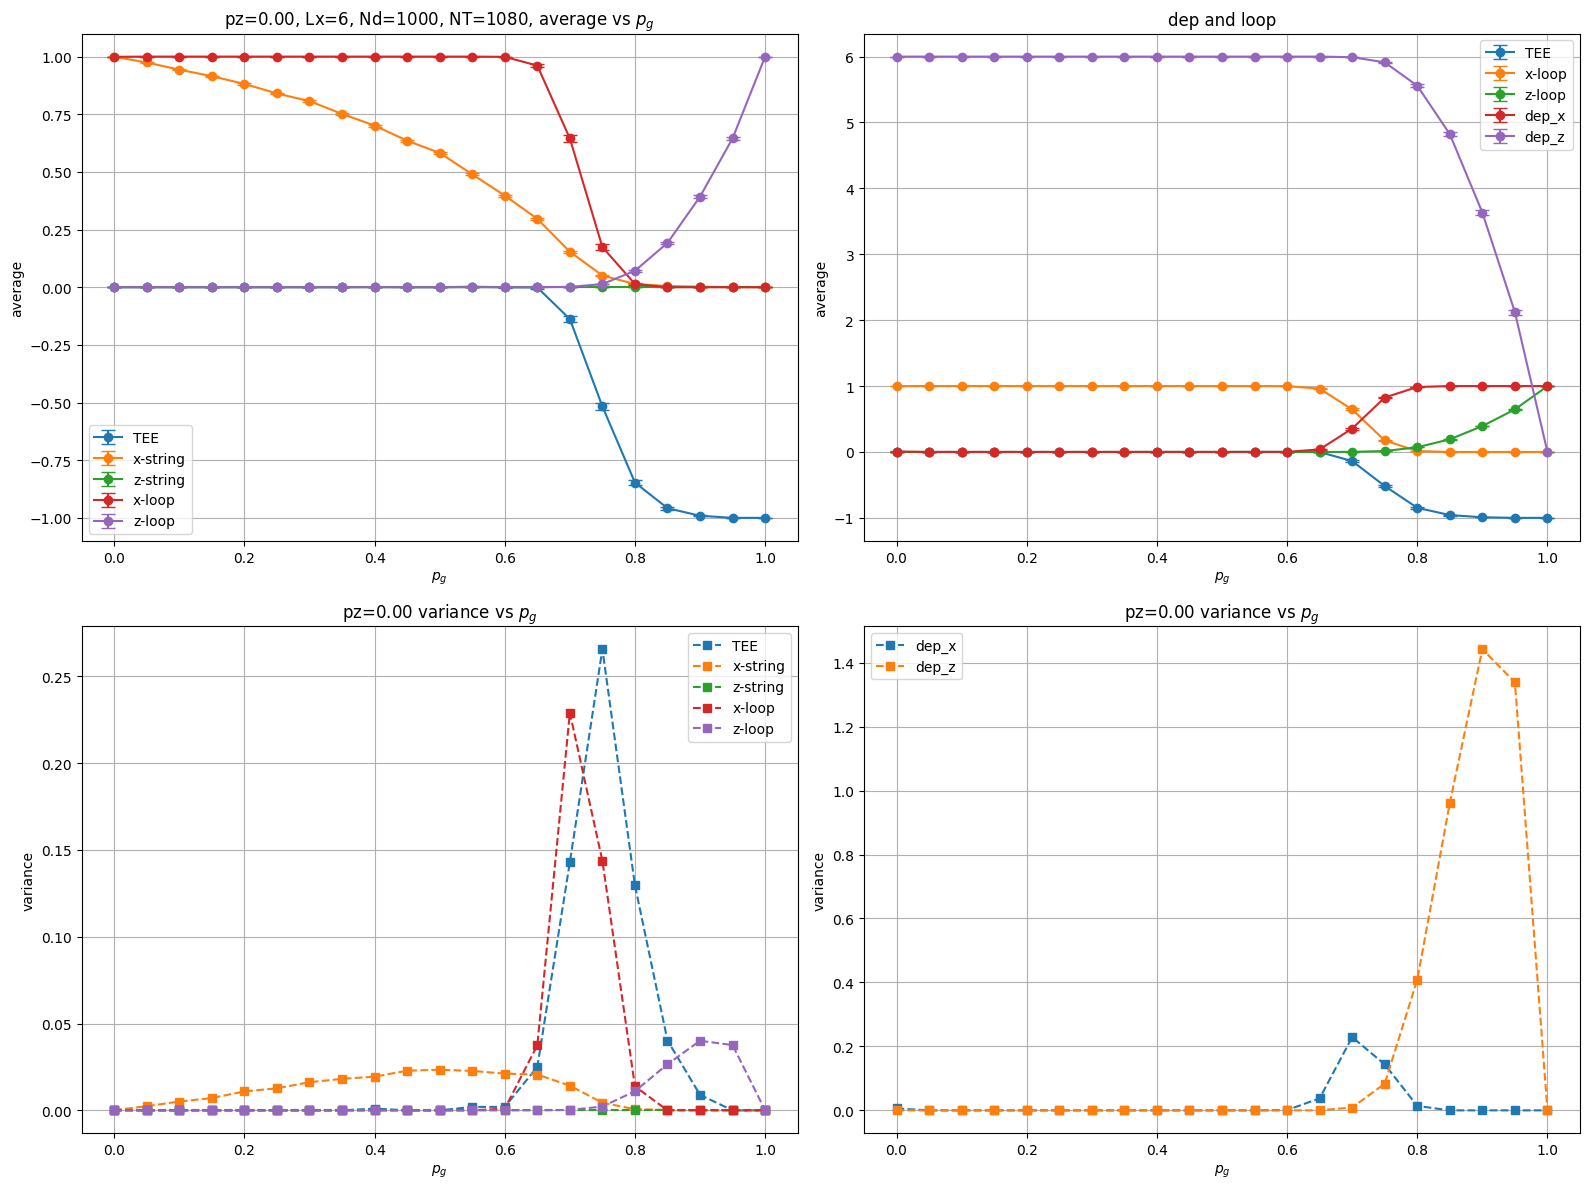

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# カラーマップ設定
cmap = plt.colormaps['gnuplot']

# ファイル読み込み
files = glob.glob("results_pz_0.0_Lx_6_Nd_1000_NT_1080.npz")
print("見つかったファイル:", files)

for file in files:
    match = re.search(
        r"pz_([0-9.]+)_Lx_(\d+)_Nd_(\d+)_NT_(\d+)", file
    )
    if match:
        pz = float(match.group(1))
        Lx = int(match.group(2))
        Nd = int(match.group(3))
        NT = int(match.group(4))
        print(f"{file} → Lx={Lx}, Nd={Nd}, NT={NT}, pz={pz}")

# プロット用
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

for file in files:
    with np.load(file) as data:
        pg = data['pg']                      # ← 必ず最初に読み込む
        sort_idx = np.argsort(pg)           # ← 昇順インデックス
        pg = pg[sort_idx]                   # ← 並び替え
                
        TEE_ave = data['TEE_ave'][sort_idx]
        TEE_err = data['TEE_err'][sort_idx]
        TEE_var = data['TEE_var'][sort_idx]
        R2x_ave = data['R2x_ave'][sort_idx]
        R2x_err = data['R2x_err'][sort_idx]
        R2x_var = data['R2x_var'][sort_idx]
        R2z_ave = data['R2z_ave'][sort_idx]
        R2z_err = data['R2z_err'][sort_idx]
        R2z_var = data['R2z_var'][sort_idx]
        R2x_loop_ave = data['R2x_loop_ave'][sort_idx]
        R2x_loop_err = data['R2x_loop_err'][sort_idx]
        R2x_loop_var = data['R2x_loop_var'][sort_idx]
        R2z_loop_ave = data['R2z_loop_ave'][sort_idx]
        R2z_loop_err = data['R2z_loop_err'][sort_idx]
        R2z_loop_var = data['R2z_loop_var'][sort_idx]
        dep_x_ave = data['dep_x_ave'][sort_idx]
        dep_x_err = data['dep_x_err'][sort_idx]
        dep_x_var = data['dep_x_var'][sort_idx]
        dep_z_ave = data['dep_z_ave'][sort_idx]
        dep_z_err = data['dep_z_err'][sort_idx]
        dep_z_var = data['dep_z_var'][sort_idx]

    #label = f"px={px:.2f}"
    #label =f"ee"
    # 左グラフ：TEEと相関の平均＋誤差
    ax[0,0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,0].errorbar(pg, R2x_ave, yerr=R2x_err, fmt='o-', capsize=5, label="x-string")
    ax[0,0].errorbar(pg, R2z_ave, yerr=R2z_err, fmt='o-', capsize=5, label="z-string")
    ax[0,0].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,0].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    # 右グラフ：分散
    ax[0,1].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,1].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,1].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")
    ax[0,1].errorbar(pg, dep_x_ave, yerr=dep_x_err, fmt='o-', capsize=5, label="dep_x")
    ax[0,1].errorbar(pg, dep_z_ave, yerr=dep_z_err, fmt='o-', capsize=5, label="dep_z")

    ax[1,0].plot(pg, TEE_var, 's--', label="TEE")    
    ax[1,0].plot(pg, R2x_var, 's--', label="x-string")
    ax[1,0].plot(pg, R2z_var, 's--', label="z-string")
    ax[1,0].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,0].plot(pg, R2z_loop_var, 's--', label="z-loop")
    
    ax[1,1].plot(pg, dep_x_var, 's--', label="dep_x")
    ax[1,1].plot(pg, dep_z_var, 's--', label="dep_z")

    print(f"{file}: Lx= {Lx}")

# 描画設定
ax[0,0].set_xlabel('$p_g$')
ax[0,0].set_ylabel('average')
ax[0,0].set_title(f"pz={pz:.2f}, Lx={Lx}, Nd={Nd}, NT={NT}, average vs $p_g$")
ax[0,0].grid(True)
ax[0,0].legend()

ax[0,1].set_xlabel('$p_g$')
ax[0,1].set_ylabel('average')
ax[0,1].set_title("dep and loop")
ax[0,1].grid(True)
ax[0,1].legend()

ax[1,0].set_xlabel('$p_g$')
ax[1,0].set_ylabel('variance')
ax[1,0].set_title(f"pz={pz:.2f} variance vs $p_g$")
ax[1,0].grid(True)
ax[1,0].legend()

ax[1,1].set_xlabel('$p_g$')
ax[1,1].set_ylabel('variance')
ax[1,1].set_title(f"pz={pz:.2f} variance vs $p_g$")
ax[1,1].grid(True)
ax[1,1].legend()

plt.tight_layout()
plt.savefig(f"Lx_{Lx}_Nd_{Nd}_NT_{NT}_pz_{pz:.2f}_results.png", dpi=300, bbox_inches='tight')
plt.show()


見つかったファイル: ['results_pz_0.0_Lx_24_Nd_500_NT_17280.npz']
results_pz_0.0_Lx_24_Nd_500_NT_17280.npz → Lx=24, Nd=500, NT=17280, pz=0.0
results_pz_0.0_Lx_24_Nd_500_NT_17280.npz: Lx= 24


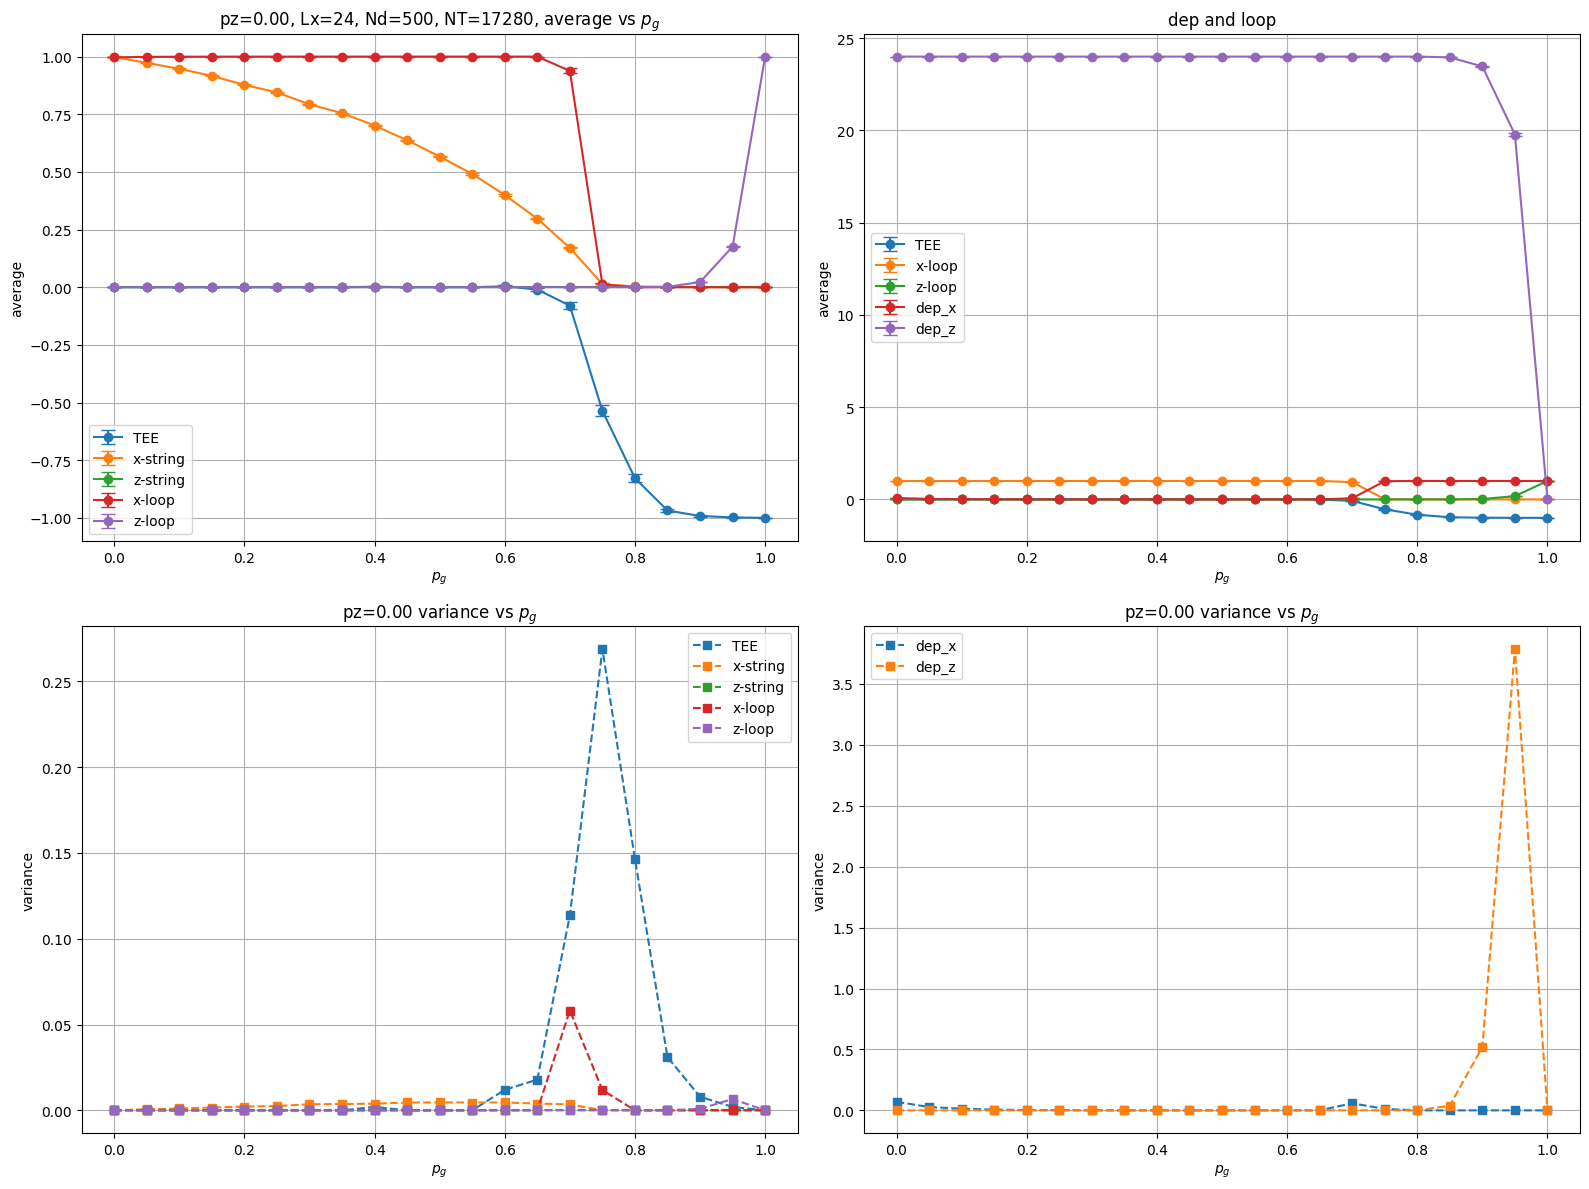

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# カラーマップ設定
cmap = plt.colormaps['gnuplot']

# ファイル読み込み
files = glob.glob("results_pz_0.0_Lx_24_Nd_500_NT_17280.npz")
print("見つかったファイル:", files)

for file in files:
    match = re.search(
        r"pz_([0-9.]+)_Lx_(\d+)_Nd_(\d+)_NT_(\d+)", file
    )
    if match:
        pz = float(match.group(1))
        Lx = int(match.group(2))
        Nd = int(match.group(3))
        NT = int(match.group(4))
        print(f"{file} → Lx={Lx}, Nd={Nd}, NT={NT}, pz={pz}")

# プロット用
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

for file in files:
    with np.load(file) as data:
        pg = data['pg']                      # ← 必ず最初に読み込む
        sort_idx = np.argsort(pg)           # ← 昇順インデックス
        pg = pg[sort_idx]                   # ← 並び替え
                
        TEE_ave = data['TEE_ave'][sort_idx]
        TEE_err = data['TEE_err'][sort_idx]
        TEE_var = data['TEE_var'][sort_idx]
        R2x_ave = data['R2x_ave'][sort_idx]
        R2x_err = data['R2x_err'][sort_idx]
        R2x_var = data['R2x_var'][sort_idx]
        R2z_ave = data['R2z_ave'][sort_idx]
        R2z_err = data['R2z_err'][sort_idx]
        R2z_var = data['R2z_var'][sort_idx]
        R2x_loop_ave = data['R2x_loop_ave'][sort_idx]
        R2x_loop_err = data['R2x_loop_err'][sort_idx]
        R2x_loop_var = data['R2x_loop_var'][sort_idx]
        R2z_loop_ave = data['R2z_loop_ave'][sort_idx]
        R2z_loop_err = data['R2z_loop_err'][sort_idx]
        R2z_loop_var = data['R2z_loop_var'][sort_idx]
        dep_x_ave = data['dep_x_ave'][sort_idx]
        dep_x_err = data['dep_x_err'][sort_idx]
        dep_x_var = data['dep_x_var'][sort_idx]
        dep_z_ave = data['dep_z_ave'][sort_idx]
        dep_z_err = data['dep_z_err'][sort_idx]
        dep_z_var = data['dep_z_var'][sort_idx]

    #label = f"px={px:.2f}"
    #label =f"ee"
    # 左グラフ：TEEと相関の平均＋誤差
    ax[0,0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,0].errorbar(pg, R2x_ave, yerr=R2x_err, fmt='o-', capsize=5, label="x-string")
    ax[0,0].errorbar(pg, R2z_ave, yerr=R2z_err, fmt='o-', capsize=5, label="z-string")
    ax[0,0].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,0].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    # 右グラフ：分散
    ax[0,1].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,1].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,1].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")
    ax[0,1].errorbar(pg, dep_x_ave, yerr=dep_x_err, fmt='o-', capsize=5, label="dep_x")
    ax[0,1].errorbar(pg, dep_z_ave, yerr=dep_z_err, fmt='o-', capsize=5, label="dep_z")

    ax[1,0].plot(pg, TEE_var, 's--', label="TEE")    
    ax[1,0].plot(pg, R2x_var, 's--', label="x-string")
    ax[1,0].plot(pg, R2z_var, 's--', label="z-string")
    ax[1,0].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,0].plot(pg, R2z_loop_var, 's--', label="z-loop")
    
    ax[1,1].plot(pg, dep_x_var, 's--', label="dep_x")
    ax[1,1].plot(pg, dep_z_var, 's--', label="dep_z")

    print(f"{file}: Lx= {Lx}")

# 描画設定
ax[0,0].set_xlabel('$p_g$')
ax[0,0].set_ylabel('average')
ax[0,0].set_title(f"pz={pz:.2f}, Lx={Lx}, Nd={Nd}, NT={NT}, average vs $p_g$")
ax[0,0].grid(True)
ax[0,0].legend()

ax[0,1].set_xlabel('$p_g$')
ax[0,1].set_ylabel('average')
ax[0,1].set_title("dep and loop")
ax[0,1].grid(True)
ax[0,1].legend()

ax[1,0].set_xlabel('$p_g$')
ax[1,0].set_ylabel('variance')
ax[1,0].set_title(f"pz={pz:.2f} variance vs $p_g$")
ax[1,0].grid(True)
ax[1,0].legend()

ax[1,1].set_xlabel('$p_g$')
ax[1,1].set_ylabel('variance')
ax[1,1].set_title(f"pz={pz:.2f} variance vs $p_g$")
ax[1,1].grid(True)
ax[1,1].legend()

plt.tight_layout()
plt.savefig(f"Lx_{Lx}_Nd_{Nd}_NT_{NT}_pz_{pz:.2f}_results.png", dpi=300, bbox_inches='tight')
plt.show()


見つかったファイル: ['px_0.0_Lx_12_MPI_results.npz']
px_0.0_Lx_12_MPI_results.npz: pg = [0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]


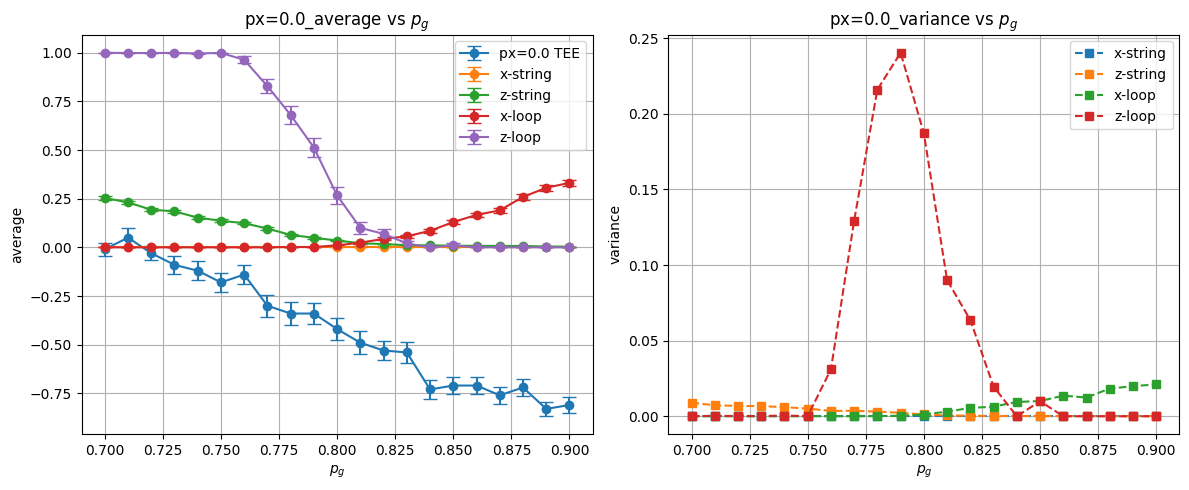

In [3]:
#### initial X
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

cmap = plt.colormaps['gnuplot']

# ファイル読み込み（Lxの数字を含むもの）
files = glob.glob("px_0.0_Lx_12_MPI_results.npz")
print("見つかったファイル:", files)

# --- Lxの数値でソート ---
lx_file_pairs = []
for file in files:
    match = re.search(r'px_([0.0-9]+)_Lx_(\d+)', file)
    #match = re.search(r'Lx_(\d+)', file)
    if match:
        px = float(match.group(1))
        Lx = int(match.group(2))
        lx_file_pairs.append((Lx, file))
    else:
        print(f"Lxの抽出失敗: {file}")

# 数値順に並べ替え（10, 12, 14, 16...）
lx_file_pairs.sort(key=lambda x: x[0])

# プロット用
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for Lx, file in lx_file_pairs:
    with np.load(file) as data:
        pg = data['pg']
        TEE_ave = data['TEE_ave']
        TEE_err = data['TEE_err']
        TEE_var = data['TEE_var']
        R2x_ave = data['R2x_ave']
        R2x_err = data['R2x_err']
        R2x_var = data['R2x_var']
        R2z_ave = data['R2z_ave']
        R2z_err = data['R2z_err']
        R2z_var = data['R2z_var']
        R2x_loop_ave = data['R2x_loop_ave']
        R2x_loop_err = data['R2x_loop_err']
        R2x_loop_var = data['R2x_loop_var']
        R2z_loop_ave = data['R2z_loop_ave']
        R2z_loop_err = data['R2z_loop_err']
        R2z_loop_var = data['R2z_loop_var']
        
    label = f"px={px}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label=f"{label} TEE")
    ax[0].errorbar(pg, R2x_ave, yerr=R2x_err, fmt='o-', capsize=5, label="x-string")
    ax[0].errorbar(pg, R2z_ave, yerr=R2z_err, fmt='o-', capsize=5, label="z-string")
    ax[0].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")
    # 右グラフ：TEEの分散
    #ax[1].plot(pg, TEE_var, 's--', label=f"{label} TEE")
    ax[1].plot(pg, R2x_var, 's--', label="x-string")
    ax[1].plot(pg, R2z_var, 's--', label="z-string")
    ax[1].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1].plot(pg, R2z_loop_var, 's--', label="z-loop")
    print(f"{file}: pg = {pg}")

# 描画設定
ax[0].set_xlabel('$p_g$')
ax[0].set_ylabel('average')
ax[0].set_title("px="+"{:}_".format(px)+"average vs $p_g$")
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('$p_g$')
ax[1].set_ylabel('variance')
ax[1].set_title("px="+"{:}_".format(px)+"variance vs $p_g$")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.savefig("px_"+"{:}".format(px)+"_Lx_"+"{:}".format(Lx)+"_MPI_results.png", dpi=300, bbox_inches='tight')
plt.show()


In [55]:
import numpy as np

data = np.load("px_0.15_Lx_10_MPI_results.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var', 'R2x_ave', 'R2x_err', 'R2x_var', 'R2z_ave', 'R2z_err', 'R2z_var', 'R2x_loop_ave', 'R2x_loop_err', 'R2x_loop_var', 'R2z_loop_ave', 'R2z_loop_err', 'R2z_loop_var']


In [106]:
import numpy as np

data = np.load("px_0.15_Lx_10_MPI_results.npz")
print(data['pg'])
print(data['R2x_ave'])
print(data['R2x_err'])
print(data['R2x_var'])
print(data['R2x_loop_ave'])
print(data['R2x_loop_err'])
print(data['R2x_loop_var'])
data.close()

[0.45 0.49 0.53 0.57 0.61 0.65 0.69 0.73 0.77 0.81 0.85]
[0.00294444 0.00316667 0.00338889 0.00333333 0.00388889 0.00383333
 0.00566667 0.00644444 0.00722222 0.00711111 0.00733333]
[0.00044887 0.00041958 0.0004606  0.00047911 0.00047748 0.00050186
 0.00056792 0.00076916 0.00072081 0.00067774 0.00076137]
[4.00956790e-05 3.50339506e-05 4.22191358e-05 4.56790123e-05
 4.53703704e-05 5.01203704e-05 6.41851852e-05 1.17728395e-04
 1.03395062e-04 9.14074074e-05 1.15358025e-04]
[0.00294444 0.00316667 0.00338889 0.00333333 0.00388889 0.00383333
 0.00566667 0.00644444 0.00722222 0.00711111 0.00733333]
[0.         0.         0.         0.         0.         0.00099243
 0.00504739 0.01038819 0.01210252 0.0110674  0.        ]
[0.         0.         0.         0.         0.         0.000196
 0.00506975 0.021475   0.02914775 0.024375   0.        ]


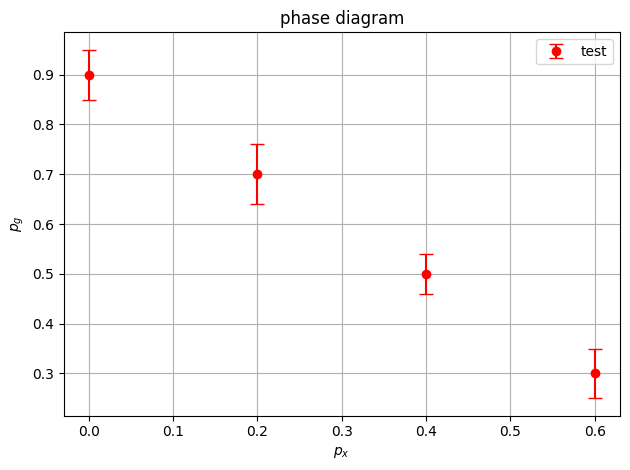

In [71]:
px = np.array([0.0, 0.2, 0.4, 0.6])
pg = np.array([0.9, 0.7, 0.5, 0.3])
pg_err = np.array([0.05, 0.06, 0.04, 0.05])  # 幅（例）

plt.errorbar(px, pg, yerr=pg_err, fmt='o', color='red', capsize=5, label="test")
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_g$')
plt.title("phase diagram")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

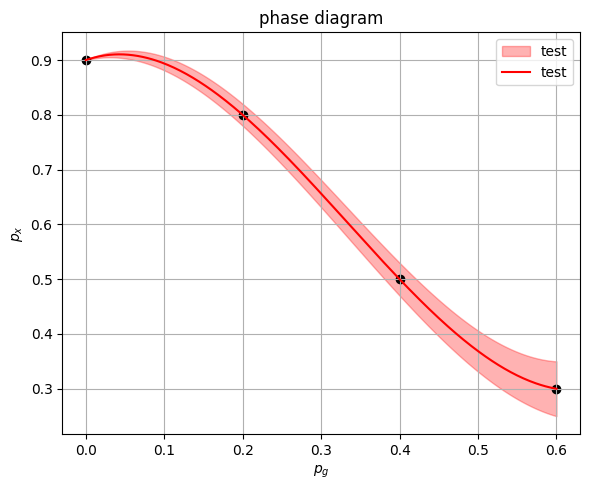

In [83]:
from scipy.interpolate import make_interp_spline

px = np.array([0.0, 0.2, 0.4, 0.6])
pg = np.array([0.9, 0.8, 0.5, 0.3])
pg_err = np.array([0.00, 0.02, 0.03, 0.05])  # 幅（例）

# 中央点と誤差
pg_upper = pg + pg_err
pg_lower = pg - pg_err

# 補間（なめらかな曲線に）
px_smooth = np.linspace(px.min(), px.max(), 300)
spline_mid = make_interp_spline(px, pg, k=3)
spline_upper = make_interp_spline(px, pg_upper, k=3)
spline_lower = make_interp_spline(px, pg_lower, k=3)

pg_smooth = spline_mid(px_smooth)
pg_smooth_upper = spline_upper(px_smooth)
pg_smooth_lower = spline_lower(px_smooth)

# 描画
plt.figure(figsize=(6, 5))
plt.fill_between(px_smooth, pg_smooth_lower, pg_smooth_upper, color='red', alpha=0.3, label='test')
plt.plot(px_smooth, pg_smooth, color='red', label='test')
plt.scatter(px, pg, color='black')
plt.xlabel(r'$p_g$')
plt.ylabel(r'$p_x$')
plt.title("phase diagram")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()